In [1]:
pwd

'C:\\Users\\PC'

In [2]:
cd downloads

C:\Users\PC\downloads


In [3]:
ls

 Volume in drive C has no label.
 Volume Serial Number is 7A33-BDF2

 Directory of C:\Users\PC\Downloads

03/04/2026  02:01 PM    <DIR>          .
03/08/2026  02:58 PM    <DIR>          ..
03/18/2025  04:32 AM           657,100 1742261440154.jpg
03/18/2025  04:32 AM           720,677 1742261440156.jpg
03/18/2025  04:32 AM           884,597 1742261440159.jpg
03/18/2025  04:32 AM           692,646 1742261440162.jpg
03/18/2025  04:32 AM           729,085 1742261440165.jpg
03/18/2025  04:32 AM           771,846 1742261440170.jpg
03/18/2025  04:32 AM            86,247 1742261440173.jpg
03/18/2025  04:32 AM           137,427 1742261440176.jpg
03/18/2025  04:32 AM            80,611 1742261440180 (1).jpg
03/18/2025  04:32 AM            80,611 1742261440180.jpg
03/18/2025  04:32 AM            82,641 1742261440184.jpg
03/18/2025  04:32 AM           116,524 1742261440187.jpg
03/18/2025  04:31 AM           109,244 1742261440191.jpg
04/08/2025  09:01 PM            98,759 20250408_KJSEA_2025_2040601

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [5]:
df = pd.read_csv("C:/Users/pc/Downloads/data (1).csv")
df.head()

,MATS3v,nHBint10,MATS3s,MATS3p,nHBDon_Lipinski,minHBint8,MATS3e,MATS3c,minHBint2,MATS3m,...,WTPT-4,WTPT-5,ETA_EtaP_L,ETA_EtaP_F,ETA_EtaP_B,nT5Ring,SHdNH,ETA_dEpsilon_C,MDEO-22,Class
0,0.0908,0,0.0075,0.0173,0,0.0,-0.0436,0.0409,0.0,0.1368,...,0.0000,0.0000,0.1780,1.5488,0.0088,0,0.0,-0.0868,0.00,NonToxic
1,0.0213,0,0.1144,-0.0410,0,0.0,0.1231,-0.0316,0.0,0.1318,...,8.8660,19.3525,0.1739,1.3718,0.0048,2,0.0,-0.0810,0.25,NonToxic
2,0.0018,0,-0.0156,-0.0765,2,0.0,-0.1138,-0.1791,0.0,0.0615,...,5.2267,27.8796,0.1688,1.4395,0.0116,2,0.0,-0.1004,0.00,NonToxic
3,-0.0251,0,-0.0064,-0.0894,3,0.0,-0.0747,-0.1151,0.0,0.0361,...,7.7896,24.7336,0.1702,1.4654,0.0133,2,0.0,-0.1010,0.00,NonToxic
4,0.0135,0,0.0424,-0.0353,0,0.0,-0.0638,0.0307,0.0,0.0306,...,12.3240,19.7486,0.1789,1.4495,0.0120,2,0.0,-0.1071,0.00,NonToxic


In [6]:
df.shape

(171, 1204)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 171 entries, 0 to 170
Columns: 1204 entries, MATS3v to Class
dtypes: float64(1003), int64(200), object(1)
memory usage: 1.6+ MB


In [8]:
df.columns

Index(['MATS3v', 'nHBint10', 'MATS3s', 'MATS3p', 'nHBDon_Lipinski',
       'minHBint8', 'MATS3e', 'MATS3c', 'minHBint2', 'MATS3m',
       ...
       'WTPT-4', 'WTPT-5', 'ETA_EtaP_L', 'ETA_EtaP_F', 'ETA_EtaP_B', 'nT5Ring',
       'SHdNH', 'ETA_dEpsilon_C', 'MDEO-22', 'Class'],
      dtype='object', length=1204)

In [9]:
df.describe()

,MATS3v,nHBint10,MATS3s,MATS3p,nHBDon_Lipinski,minHBint8,MATS3e,MATS3c,minHBint2,MATS3m,...,WTPT-3,WTPT-4,WTPT-5,ETA_EtaP_L,ETA_EtaP_F,ETA_EtaP_B,nT5Ring,SHdNH,ETA_dEpsilon_C,MDEO-22
count,171.000000,171.000000,171.000000,171.000000,171.000000,171.000000,171.000000,171.000000,171.000000,171.000000,...,171.000000,171.000000,171.000000,171.000000,171.000000,171.000000,171.000000,171.000000,171.000000,171.000000
mean,-0.031244,0.315789,-0.001001,-0.061501,0.994152,0.677770,-0.025418,-0.053289,1.569251,0.003226,...,23.229975,8.134013,13.490291,0.202529,1.235093,0.011316,1.467836,0.004820,-0.085088,0.061702
std,0.063559,0.762918,0.063928,0.072891,1.108773,1.647322,0.078645,0.109463,2.497362,0.074076,...,6.440623,4.436831,6.229089,0.024356,0.137024,0.005482,1.013361,0.044475,0.029273,0.241896
min,-0.311500,0.000000,-0.184600,-0.348500,0.000000,0.000000,-0.211900,-0.472900,-0.708700,-0.198700,...,0.000000,0.000000,0.000000,0.163600,0.811500,0.001400,0.000000,0.000000,-0.202700,0.000000
25%,-0.066700,0.000000,-0.036000,-0.099550,0.000000,0.000000,-0.066550,-0.118050,0.000000,-0.052350,...,19.249600,5.164700,8.819950,0.182450,1.149750,0.007550,1.000000,0.000000,-0.099500,0.000000
50%,-0.032500,0.000000,-0.002000,-0.059400,1.000000,0.000000,-0.037200,-0.042400,0.000000,-0.001600,...,23.151200,7.848200,13.342700,0.199600,1.238800,0.010700,1.000000,0.000000,-0.082400,0.000000
75%,0.004850,0.000000,0.029000,-0.017100,2.000000,0.000000,0.002650,0.014300,4.897450,0.056550,...,26.958050,10.683950,19.319450,0.219700,1.325350,0.013900,2.000000,0.000000,-0.066350,0.000000
max,0.141100,4.000000,0.218100,0.129000,6.000000,8.141400,0.249500,0.212200,7.740800,0.168400,...,41.380000,20.805400,27.879600,0.272100,1.548800,0.034600,5.000000,0.429200,-0.007300,2.636100


In [10]:
df.isnull().sum()

MATS3v             0
nHBint10           0
MATS3s             0
MATS3p             0
nHBDon_Lipinski    0
                  ..
nT5Ring            0
SHdNH              0
ETA_dEpsilon_C     0
MDEO-22            0
Class              0
Length: 1204, dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df["Class"].value_counts()

Class
NonToxic    115
Toxic        56
Name: count, dtype: int64

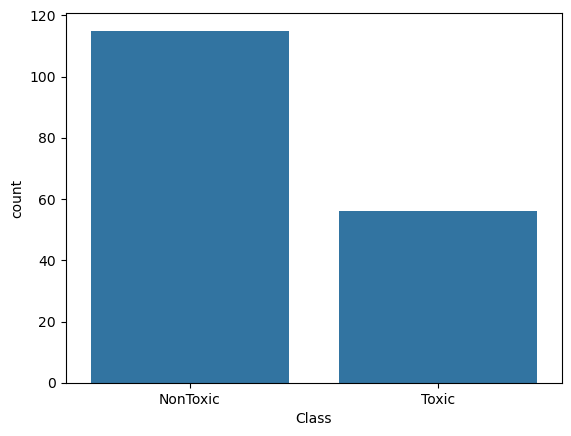

In [13]:
sns.countplot(x="Class", data=df)
plt.show()

In [14]:
le = LabelEncoder()
df["Class"] = le.fit_transform(df["Class"])

In [15]:
df["Class"].unique()

array([0, 1])

In [16]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [17]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [18]:
selector = SelectKBest(score_func=f_classif, k=5)
X_selected = selector.fit_transform(X_scaled, y)

In [19]:
selected_features = X.columns[selector.get_support()]
selected_features

Index(['SpDiam_Dt', 'EE_Dt', 'C2SP2', 'MLogP', 'AATSC7p'], dtype='object')

In [20]:
model = LogisticRegression()

scores = cross_val_score(model, X_selected, y, cv=5)

print("Cross-validation scores:", scores)
print("Mean accuracy:", scores.mean())

Cross-validation scores: [0.6        0.61764706 0.67647059 0.64705882 0.70588235]
Mean accuracy: 0.6494117647058825


In [21]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("feature_selection", SelectKBest(f_classif, k=5)),
    ("model", LogisticRegression())
])

scores = cross_val_score(pipeline, X, y, cv=5)

print("Cross-validation scores:", scores)
print("Mean accuracy:", scores.mean())

Cross-validation scores: [0.54285714 0.61764706 0.61764706 0.61764706 0.5       ]
Mean accuracy: 0.5791596638655462


C:\Users\PC\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [ 203  214  253  378  702  759  989 1028 1035 1110] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [ 96 186 733 853 949] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [  64   69  197  240  263  301  327  352  522  564  

In [22]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf_scores = cross_val_score(rf, X, y, cv=5)

print("Random Forest CV Scores:", rf_scores)
print("Mean Accuracy:", rf_scores.mean())

Random Forest CV Scores: [0.51428571 0.58823529 0.52941176 0.64705882 0.70588235]
Mean Accuracy: 0.5969747899159664


In [23]:
gb = GradientBoostingClassifier()

gb_scores = cross_val_score(gb, X, y, cv=5)

print("Gradient Boosting CV Scores:", gb_scores)
print("Mean Accuracy:", gb_scores.mean())

Gradient Boosting CV Scores: [0.48571429 0.41176471 0.55882353 0.61764706 0.64705882]
Mean Accuracy: 0.5442016806722688


In [24]:
ada = AdaBoostClassifier()

ada_scores = cross_val_score(ada, X, y, cv=5)

print("AdaBoost CV Scores:", ada_scores)
print("Mean Accuracy:", ada_scores.mean())

AdaBoost CV Scores: [0.48571429 0.58823529 0.5        0.67647059 0.70588235]
Mean Accuracy: 0.5912605042016807


In [25]:
scoring = ['accuracy', 'precision', 'recall', 'f1']

In [26]:
voting = VotingClassifier(
    estimators=[
        ('rf', rf),
        ('gb', gb),
        ('ada', ada)
    ],
    voting='hard'
)

voting_scores = cross_val_score(voting, X, y, cv=5)

print("Voting Classifier CV Scores:", voting_scores)
print("Mean Accuracy:", voting_scores.mean())

Voting Classifier CV Scores: [0.45714286 0.52941176 0.5        0.64705882 0.70588235]
Mean Accuracy: 0.5678991596638656


In [27]:
results = {
    "Random Forest": rf_scores.mean(),
    "Gradient Boosting": gb_scores.mean(),
    "AdaBoost": ada_scores.mean(),
    "Voting Ensemble": voting_scores.mean()
}

results

{'Random Forest': np.float64(0.5969747899159664),
 'Gradient Boosting': np.float64(0.5442016806722688),
 'AdaBoost': np.float64(0.5912605042016807),
 'Voting Ensemble': np.float64(0.5678991596638656)}

In [28]:
cv = StratifiedKFold(n_splits=5)

In [29]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

In [30]:


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [31]:


selector = SelectKBest(score_func=f_classif, k=5)

X_selected = selector.fit_transform(X_scaled, y)

In [32]:
selected_features = X.columns[selector.get_support()]
print(selected_features)

Index(['SpDiam_Dt', 'EE_Dt', 'C2SP2', 'MLogP', 'AATSC7p'], dtype='object')


In [33]:
rf_eval = cross_validate(rf, X_selected, y, cv=cv, scoring=scoring)

In [34]:
print("Accuracy:", rf_eval['test_accuracy'].mean())
print("Precision:", rf_eval['test_precision'].mean())
print("Recall:", rf_eval['test_recall'].mean())
print("F1 Score:", rf_eval['test_f1'].mean())

Accuracy: 0.6438655462184875
Precision: 0.5037362637362637
Recall: 0.3742424242424242
F1 Score: 0.3919851887243192


In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42
)

In [37]:
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [38]:
y_pred = rf.predict(X_test)

In [44]:
cm=confusion_matrix(y_test, y_pred)

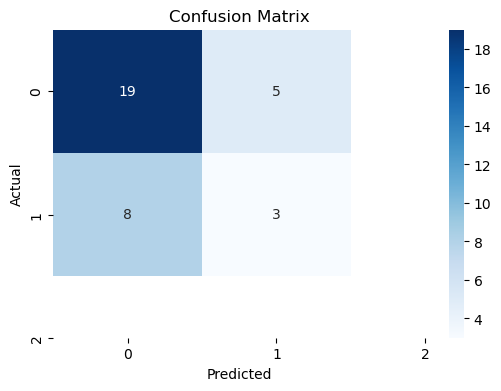

In [45]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0,1,2], yticklabels=[0,1,2])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [49]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.70      0.79      0.75        24
           1       0.38      0.27      0.32        11

    accuracy                           0.63        35
   macro avg       0.54      0.53      0.53        35
weighted avg       0.60      0.63      0.61        35



In [ ]:
df.iloc[:-1, :-1].plot(kind='bar', figsize=(8,6))
plt.title("Classification Report Metrics")
plt.ylabel("Score")
plt.ylim(0,1)
plt.show()
